# Notebook 1: Data Exploration

This notebook loads and explores the SEED-VIG EEG dataset with all 4 feature types:
- de_LDS, de_movingAve, psd_LDS, psd_movingAve

**Goals:**
1. Load data from all 23 recording sessions (21 subjects, some with multiple sessions)
2. Verify shapes and data types
3. Analyze PERCLOS label distribution
4. Visualize sample EEG features
5. Check for missing values or anomalies

In [14]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Setup Paths

In [15]:
# Base directory
BASE_DIR = Path('/home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/SEED-VIG')

EEG_DIR = BASE_DIR / 'EEG_Feature_5Bands'
LABEL_DIR = BASE_DIR / 'perclos_labels'

print(f"EEG Directory: {EEG_DIR}")
print(f"Label Directory: {LABEL_DIR}")
print(f"\nEEG Directory exists: {EEG_DIR.exists()}")
print(f"Label Directory exists: {LABEL_DIR.exists()}")

EEG Directory: /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/SEED-VIG/EEG_Feature_5Bands
Label Directory: /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/SEED-VIG/perclos_labels

EEG Directory exists: True
Label Directory exists: True


## 2. List All Data Files

In [16]:
# Get all .mat files
eeg_files = sorted(list(EEG_DIR.glob('*.mat')))
label_files = sorted(list(LABEL_DIR.glob('*.mat')))

print(f"Number of EEG files: {len(eeg_files)}")
print(f"Number of label files: {len(label_files)}")
print(f"\nFirst 5 EEG files:")
for f in eeg_files[:5]:
    print(f"  {f.name}")

print(f"\nFirst 5 label files:")
for f in label_files[:5]:
    print(f"  {f.name}")

Number of EEG files: 23
Number of label files: 23

First 5 EEG files:
  10_20151125_noon.mat
  11_20151024_night.mat
  12_20150928_noon.mat
  13_20150929_noon.mat
  14_20151014_night.mat

First 5 label files:
  10_20151125_noon.mat
  11_20151024_night.mat
  12_20150928_noon.mat
  13_20150929_noon.mat
  14_20151014_night.mat


## 3. Load Sample File and Explore Structure

In [17]:
# Load one sample file to understand structure
sample_eeg_file = eeg_files[0]
sample_label_file = label_files[0]

print(f"Loading sample file: {sample_eeg_file.name}")

# Load EEG features
eeg_data = sio.loadmat(str(sample_eeg_file))

# Print all keys in the .mat file
print(f"\nKeys in EEG file:")
for key in eeg_data.keys():
    if not key.startswith('__'):
        data_shape = eeg_data[key].shape if hasattr(eeg_data[key], 'shape') else 'N/A'
        data_type = type(eeg_data[key]).__name__
        print(f"  {key}: shape={data_shape}, type={data_type}")

Loading sample file: 10_20151125_noon.mat

Keys in EEG file:
  psd_movingAve: shape=(17, 885, 5), type=ndarray
  psd_LDS: shape=(17, 885, 5), type=ndarray
  de_movingAve: shape=(17, 885, 5), type=ndarray
  de_LDS: shape=(17, 885, 5), type=ndarray


In [18]:
# Load label file
label_data = sio.loadmat(str(sample_label_file))

print(f"\nKeys in label file:")
for key in label_data.keys():
    if not key.startswith('__'):
        data_shape = label_data[key].shape if hasattr(label_data[key], 'shape') else 'N/A'
        data_type = type(label_data[key]).__name__
        print(f"  {key}: shape={data_shape}, type={data_type}")


Keys in label file:
  perclos: shape=(885, 1), type=ndarray


## 4. Explore All 4 Feature Types

In [19]:
# Explore all 4 feature types from the sample file
feature_keys = ['de_LDS', 'de_movingAve', 'psd_LDS', 'psd_movingAve']

print("\n" + "="*60)
print("Feature Type Analysis")
print("="*60)

for feat_key in feature_keys:
    if feat_key in eeg_data:
        feat = eeg_data[feat_key]
        print(f"\n{feat_key}:")
        print(f"  Shape: {feat.shape}")  # Expected: (17, 885, 5)
        print(f"  Data type: {feat.dtype}")
        print(f"  Min value: {feat.min():.4f}")
        print(f"  Max value: {feat.max():.4f}")
        print(f"  Mean value: {feat.mean():.4f}")
        print(f"  Std value: {feat.std():.4f}")
    else:
        print(f"\n{feat_key}: NOT FOUND")


Feature Type Analysis

de_LDS:
  Shape: (17, 885, 5)
  Data type: float64
  Min value: 15.5303
  Max value: 27.2969
  Mean value: 21.3671
  Std value: 2.4119

de_movingAve:
  Shape: (17, 885, 5)
  Data type: float64
  Min value: 15.5003
  Max value: 27.8051
  Mean value: 21.3689
  Std value: 2.4183

psd_LDS:
  Shape: (17, 885, 5)
  Data type: float64
  Min value: 478.4687
  Max value: 25460418.4646
  Mean value: 161757.3304
  Std value: 491735.0467

psd_movingAve:
  Shape: (17, 885, 5)
  Data type: float64
  Min value: 468.6547
  Max value: 25381747.6570
  Mean value: 161791.0475
  Std value: 494405.2981


## 5. Analyze PERCLOS Labels

In [20]:
# Extract PERCLOS labels
perclos_key = 'perclos' if 'perclos' in label_data else list(label_data.keys())[0]
perclos = label_data[perclos_key].squeeze()

print(f"\nPERCLOS Labels:")
print(f"  Shape: {perclos.shape}")  # Expected: (885,)
print(f"  Data type: {perclos.dtype}")
print(f"  Min: {perclos.min():.4f}")
print(f"  Max: {perclos.max():.4f}")
print(f"  Mean: {perclos.mean():.4f}")
print(f"  Median: {np.median(perclos):.4f}")
print(f"  Std: {perclos.std():.4f}")

# Distribution statistics
print(f"\nLabel Distribution (binned):")
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Very Drowsy\n[0-0.2)', 'Drowsy\n[0.2-0.4)', 'Neutral\n[0.4-0.6)', 'Alert\n[0.6-0.8)', 'Very Alert\n[0.8-1.0]']
hist, _ = np.histogram(perclos, bins=bins)
for i, (label, count) in enumerate(zip(labels, hist)):
    pct = 100 * count / len(perclos)
    print(f"  {label.replace(chr(10), ' ')}: {count:4d} samples ({pct:5.1f}%)")


PERCLOS Labels:
  Shape: (885,)
  Data type: float64
  Min: 0.1075
  Max: 0.7999
  Mean: 0.4314
  Median: 0.4176
  Std: 0.1456

Label Distribution (binned):
  Very Drowsy [0-0.2):   44 samples (  5.0%)
  Drowsy [0.2-0.4):  364 samples ( 41.1%)
  Neutral [0.4-0.6):  353 samples ( 39.9%)
  Alert [0.6-0.8):  124 samples ( 14.0%)
  Very Alert [0.8-1.0]:    0 samples (  0.0%)


## 6. Visualize Label Distribution

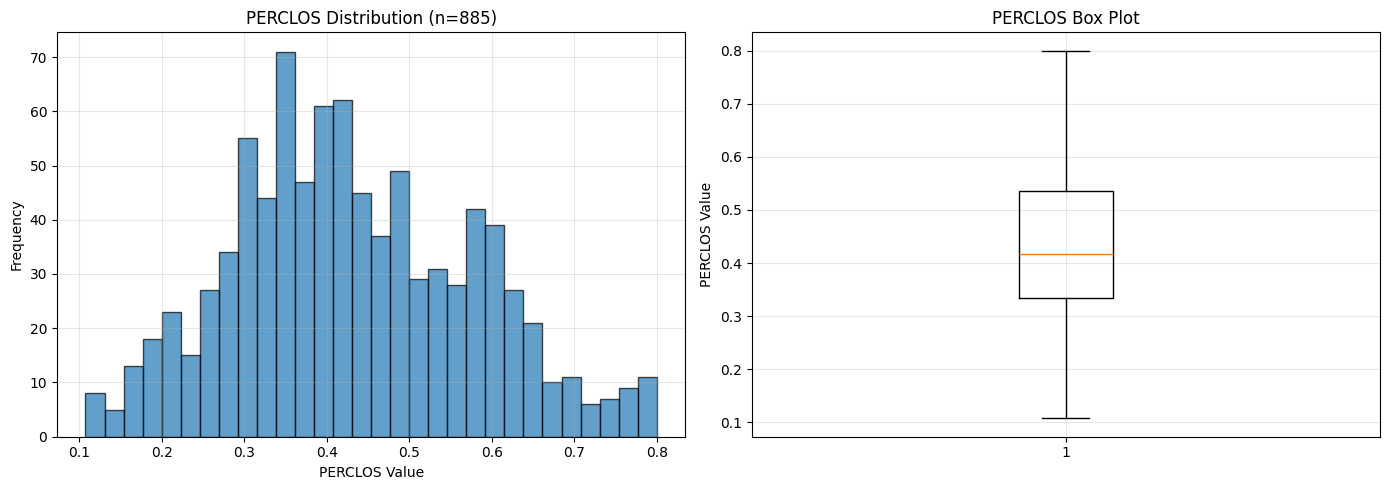


Interpretation:
  PERCLOS values close to 0 indicate high drowsiness/fatigue
  PERCLOS values close to 1 indicate high alertness


In [21]:
plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(perclos, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('PERCLOS Value')
plt.ylabel('Frequency')
plt.title(f'PERCLOS Distribution (n={len(perclos)})')
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(perclos, vert=True)
plt.ylabel('PERCLOS Value')
plt.title('PERCLOS Box Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  PERCLOS values close to 0 indicate high drowsiness/fatigue")
print(f"  PERCLOS values close to 1 indicate high alertness")

## 7. Visualize Sample EEG Features

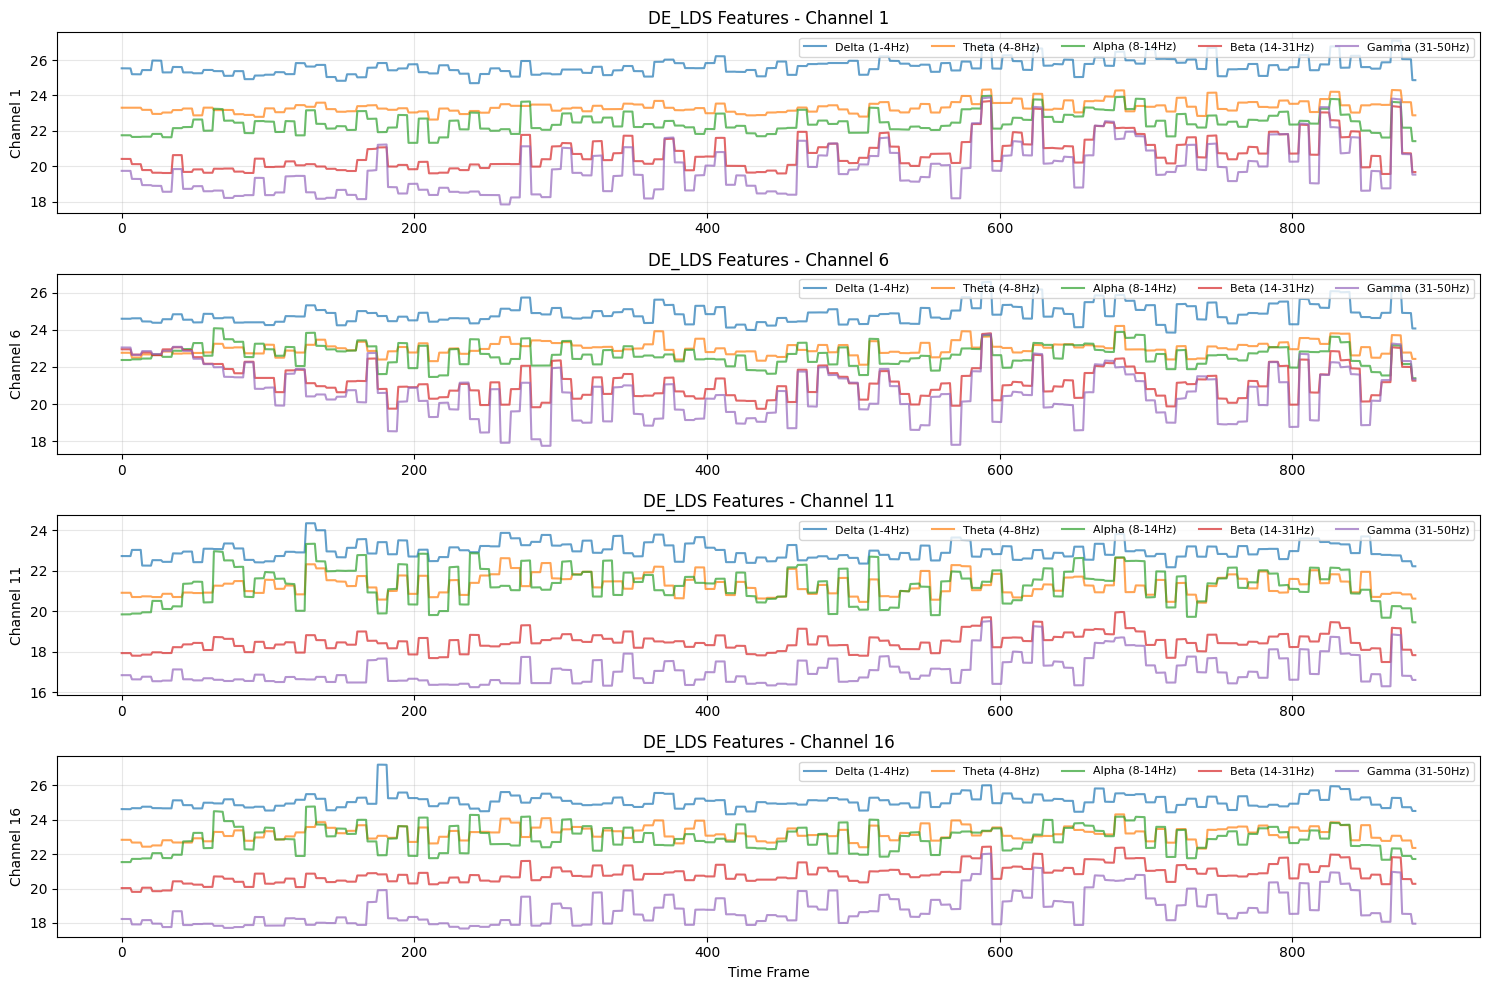

In [22]:
# Visualize de_LDS features for all 5 frequency bands
de_lds = eeg_data['de_LDS']  # Shape: (17 channels, 885 samples, 5 bands)

# Select a few channels to visualize
channels_to_plot = [0, 5, 10, 15]  # Plot 4 channels
band_names = ['Delta (1-4Hz)', 'Theta (4-8Hz)', 'Alpha (8-14Hz)', 'Beta (14-31Hz)', 'Gamma (31-50Hz)']

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(15, 10))

for idx, ch in enumerate(channels_to_plot):
    ax = axes[idx]
    for band in range(5):
        ax.plot(de_lds[ch, :, band], label=band_names[band], alpha=0.7)
    
    ax.set_ylabel(f'Channel {ch+1}')
    ax.set_title(f'DE_LDS Features - Channel {ch+1}')
    ax.legend(loc='upper right', ncol=5, fontsize=8)
    ax.grid(True, alpha=0.3)
    
    if idx == len(channels_to_plot) - 1:
        ax.set_xlabel('Time Frame')

plt.tight_layout()
plt.show()

## 8. Visualize Feature as Heatmap (17 channels × 5 bands)

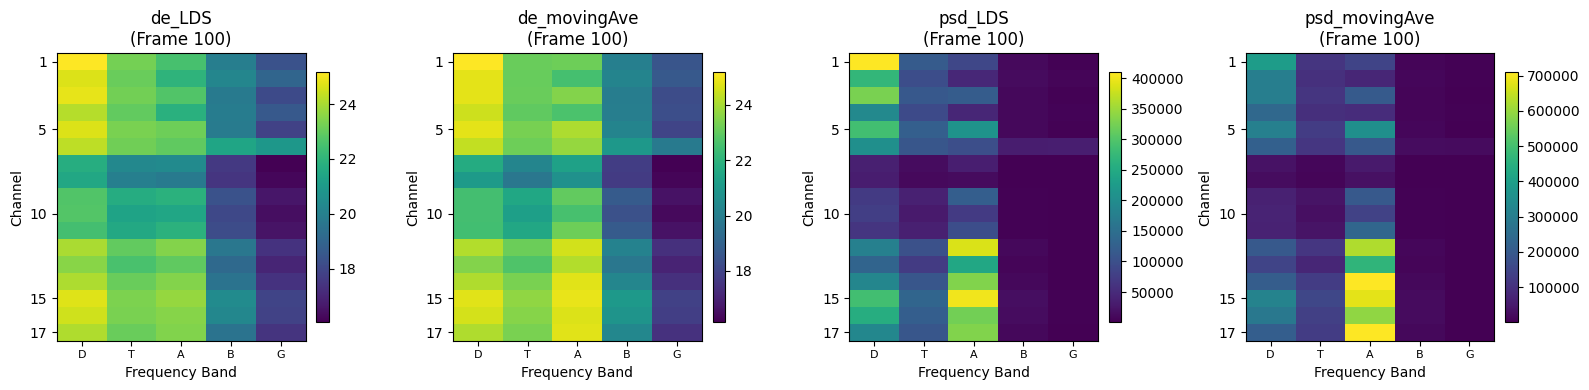


Band abbreviations: D=Delta, T=Theta, A=Alpha, B=Beta, G=Gamma
PERCLOS at frame 100: 0.3902


In [23]:
# Visualize a single time frame as heatmap
sample_frame = 100  # Pick frame 100

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, feat_key in enumerate(feature_keys):
    feat = eeg_data[feat_key]  # (17, 885, 5)
    frame_data = feat[:, sample_frame, :]  # (17, 5)
    
    ax = axes[idx]
    im = ax.imshow(frame_data, aspect='auto', cmap='viridis')
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Channel')
    ax.set_title(f'{feat_key}\n(Frame {sample_frame})')
    ax.set_xticks(range(5))
    ax.set_xticklabels(['D', 'T', 'A', 'B', 'G'], fontsize=8)
    ax.set_yticks([0, 4, 9, 14, 16])
    ax.set_yticklabels(['1', '5', '10', '15', '17'])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"\nBand abbreviations: D=Delta, T=Theta, A=Alpha, B=Beta, G=Gamma")
print(f"PERCLOS at frame {sample_frame}: {perclos[sample_frame]:.4f}")

## 9. Load ALL Sessions and Verify Dataset Integrity

In [24]:
def load_all_data(eeg_dir, label_dir, feature_key='de_LDS'):
    """
    Load all sessions' data.
    
    Returns:
        X_all: (N_total, 17, 5) - all EEG features
        y_all: (N_total,) - all PERCLOS labels
        subj_ids: (N_total,) - subject ID for each sample
        file_names: list of filenames
    """
    eeg_files = sorted(list(eeg_dir.glob('*.mat')))
    label_files = sorted(list(label_dir.glob('*.mat')))
    
    assert len(eeg_files) == len(label_files), "Mismatch in EEG and label file counts!"
    
    X_list = []
    y_list = []
    subj_id_list = []
    file_names = []
    
    print(f"Loading {len(eeg_files)} recording sessions...")
    
    for idx, (eeg_file, label_file) in enumerate(zip(eeg_files, label_files)):
        # Verify file names match
        if eeg_file.stem != label_file.stem:
            print(f"WARNING: File name mismatch at index {idx}")
            print(f"  EEG: {eeg_file.name}")
            print(f"  Label: {label_file.name}")
            continue
        
        # Load data
        eeg_data = sio.loadmat(str(eeg_file))
        label_data = sio.loadmat(str(label_file))
        
        # Extract features and labels
        if feature_key not in eeg_data:
            print(f"WARNING: {feature_key} not found in {eeg_file.name}")
            continue
        
        X = eeg_data[feature_key]  # (17, 885, 5)
        
        # Find PERCLOS key
        perclos_key = 'perclos' if 'perclos' in label_data else [k for k in label_data.keys() if not k.startswith('__')][0]
        y = label_data[perclos_key].squeeze()  # (885,)
        
        # Transpose X to (885, 17, 5)
        X = X.transpose(1, 0, 2)
        
        # Verify shapes match
        if X.shape[0] != y.shape[0]:
            print(f"WARNING: Shape mismatch in {eeg_file.name}")
            print(f"  X shape: {X.shape}, y shape: {y.shape}")
            continue
        
        # Extract subject ID from filename (e.g., "1_20151124_noon_2.mat" -> 1)
        subj_id = int(eeg_file.stem.split('_')[0])
        
        # Append to lists
        X_list.append(X)
        y_list.append(y)
        subj_id_list.append(np.full(len(y), subj_id))
        file_names.append(eeg_file.stem)
        
        if (idx + 1) % 5 == 0:
            print(f"  Loaded {idx + 1}/{len(eeg_files)} sessions...")
    
    # Concatenate all data
    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    subj_ids = np.concatenate(subj_id_list, axis=0)
    
    print(f"\nLoading complete!")
    print(f"  Total samples: {len(X_all)}")
    print(f"  X shape: {X_all.shape}")
    print(f"  y shape: {y_all.shape}")
    print(f"  Unique subjects: {len(np.unique(subj_ids))}")
    
    return X_all, y_all, subj_ids, file_names

# Load data with de_LDS features
X_all, y_all, subj_ids, file_names = load_all_data(EEG_DIR, LABEL_DIR, feature_key='de_LDS')

Loading 23 recording sessions...
  Loaded 5/23 sessions...
  Loaded 10/23 sessions...
  Loaded 15/23 sessions...
  Loaded 20/23 sessions...

Loading complete!
  Total samples: 20355
  X shape: (20355, 17, 5)
  y shape: (20355,)
  Unique subjects: 21


## 10. Dataset Statistics

In [25]:
print("Dataset Statistics:")
print("="*60)
print(f"Total samples: {len(X_all):,}")
print(f"Feature shape: {X_all.shape}")
print(f"Label shape: {y_all.shape}")
print(f"\nNumber of unique subjects: {len(np.unique(subj_ids))}")
print(f"Subject IDs: {sorted(np.unique(subj_ids))}")
print(f"Note: Some subjects have multiple recording sessions")

print(f"\nSamples per subject:")
for subj_id in sorted(np.unique(subj_ids)):
    n_samples = np.sum(subj_ids == subj_id)
    n_sessions = n_samples // 885  # Each session has 885 samples
    print(f"  Subject {subj_id:2d}: {n_samples:4d} samples ({n_sessions} session{'s' if n_sessions > 1 else ''})")

print(f"\nOverall PERCLOS statistics:")
print(f"  Min: {y_all.min():.4f}")
print(f"  Max: {y_all.max():.4f}")
print(f"  Mean: {y_all.mean():.4f}")
print(f"  Median: {np.median(y_all):.4f}")
print(f"  Std: {y_all.std():.4f}")

# Check for missing values
print(f"\nData quality checks:")
print(f"  NaN in features: {np.isnan(X_all).sum()}")
print(f"  NaN in labels: {np.isnan(y_all).sum()}")
print(f"  Inf in features: {np.isinf(X_all).sum()}")
print(f"  Inf in labels: {np.isinf(y_all).sum()}")

Dataset Statistics:
Total samples: 20,355
Feature shape: (20355, 17, 5)
Label shape: (20355,)

Number of unique subjects: 21
Subject IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Note: Some subjects have multiple recording sessions

Samples per subject:
  Subject  1:  885 samples (1 session)
  Subject  2:  885 samples (1 session)
  Subject  3:  885 samples (1 session)
  Subject  4: 1770 samples (2 sessions)
  Subject  5: 1770 samples (2 sessions)
  Subject  6:  885 samples (1 session)
  Subject  7:  885 samples (1 session)
  Subject  8:  885 samples (1 session)
  Subject  9:  885 samples (1 session)
  Subject 10:  885 samples (1 session)
  Subject 11:  885 samples (1 session)
  Subject 12:  885 samples (1 session)
  Subject 13:  885 samples (1 s

## 11. Binary Classification Label Distribution

In [26]:
# Create binary labels (for classification task)
PERCLOS_THRESHOLD = 0.35

y_binary = (y_all >= PERCLOS_THRESHOLD).astype(int)
# 0 = fatigued (PERCLOS < 0.35), 1 = alert (PERCLOS >= 0.35)

print(f"Binary Classification Labels (threshold = {PERCLOS_THRESHOLD}):")
print(f"  Class 0 (Fatigued): {np.sum(y_binary == 0):5d} samples ({100*np.mean(y_binary == 0):.1f}%)")
print(f"  Class 1 (Alert):    {np.sum(y_binary == 1):5d} samples ({100*np.mean(y_binary == 1):.1f}%)")
print(f"  Class balance ratio: {np.sum(y_binary == 0) / np.sum(y_binary == 1):.2f}")

Binary Classification Labels (threshold = 0.35):
  Class 0 (Fatigued):  7405 samples (36.4%)
  Class 1 (Alert):    12950 samples (63.6%)
  Class balance ratio: 0.57


## 12. Summary and Conclusions

**Dataset verified successfully!**

Key findings:
- 23 experiment sessions from 21 unique subjects
- Each session has 885 time frames
- Total: 20,355 samples
- 17 EEG channels × 5 frequency bands
- 4 feature types available: de_LDS, de_movingAve, psd_LDS, psd_movingAve
- PERCLOS labels are continuous [0,1]
- No missing values detected

**Ready to proceed to model training!**